<a href="https://colab.research.google.com/github/kamil0sek1/kursAI/blob/main/lekcja11_regresja_liniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **2. REGRESJA LINIOWA - WPROWADZENIE [40 MINUT - do przerwy]**
- [Linear Regression in 3 Minutes](https://youtu.be/3dhcmeOTZ_Q?si=A8cpSIcT3leM6Uja)

Regresja liniowa - metoda, która próbuje przewidzieć jedną wartość na podstawie drugiej, np.:
- przewidzieć cenę samochodu na podstawie jego wieku,
- przewidzieć liczbę punktów na podstawie czasu nauki,
- przewidzieć liczbę wykopanych diamentów na podstawie liczby godzin gry.

Regresja liniowa szuka takiej prostej linii, która najlepiej pasuje do punktów z danych.

```
y=ax+b
```
|   Symbol   | Znaczenie                                  |
| ---------- | -------------------------------------------|
|     x      | dana wejściowa, np. liczba godzin gry      |
|     y      | przewidywana wartość, np. liczba diamentów |
|     a      | nachylenie prostej                         |
|     b      | miejsce przecięcia z osią Y                |


---


**PRZYKŁAD:**

| Godziny gry| Diamenty|
| ---------- | ------- |
|          1 |       2 |
|          2 |       4 |
|          3 |       6 |

Regresja liniowa próbuje narysować prostą, która opisuje tę zależność:
```
                y=2x

Czyli:
- dla 1 godziny → około 2 diamenty,
- dla 2 godzin → około 4 diamenty,
- dla 5 godzin → około 10 diamentów.
```

---
**METODA NAJMNIEJSZYCH KWADRATÓW**

Punkty z danych zwykle nie leżą idealnie na jednej prostej.

Dlatego regresja liniowa szuka takiej prostej, żeby błędy przewidywania były jak najmniejsze.

Błąd to różnica między:

* prawdziwą wartością,
* wartością przewidzianą przez prostą.
```
Regresja przesuwa prostą tak, żeby była jak najbliżej wszystkich punktów.
```
---
| Gdzie                     | Po co?                                             |
| ------------------------- | -------------------------------------------------- |
| **Przewidywanie cen**     | np. cena mieszkania, samochodu                     |
| **Prognozowanie wyników** | np. wynik testu na podstawie godzin nauki          |
| **Analiza finansowa**     | np. przewidywanie sprzedaży                        |
| **Prognozowanie pogody**  | np. temperatura na podstawie wcześniejszych danych |
| **Uczenie maszynowe**     | jako prosty model przewidujący liczby              |

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas

In [12]:
def regression(x_data, y_data):
  sum_of_xy = 0
  sum_of_x = 0
  sum_of_y = 0
  sum_x_squared = 0
  n = len(x_data)
  for x, y in zip(x_data, y_data):
    sum_of_xy += x * y
    sum_of_x += x
    sum_of_y += y
    sum_x_squared += x ** 2


  a = (n * sum_of_xy - sum_of_x * sum_of_y) / (n * sum_x_squared - sum_of_x ** 2)

  b = (sum_of_y - a * sum_of_x) / n

  print(f"wzór:y - {a}x + {b}")

  return a, b





wzór:y - 2.0169544554455414x + -10.513861386138528


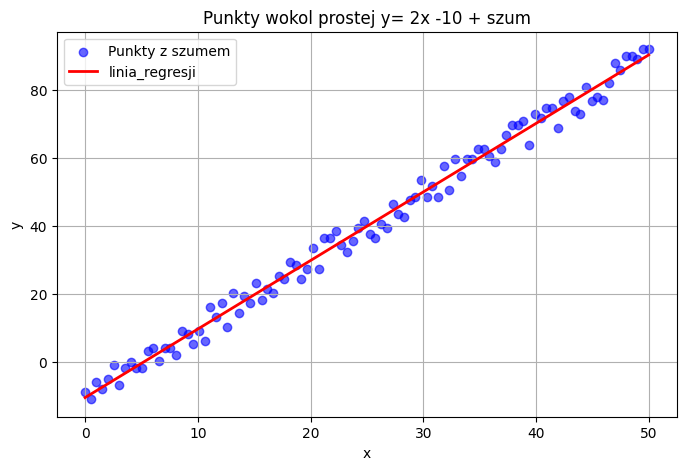

In [17]:
# ZADANIE 1 - wartości
# Korzystając z poznanych bibliotek wygeneruj 100 punktów leżących na osi
#         y(x) = 2x - 10 + szum na przedziale x <0;50)
# Szumem niech będą losowe liczby z zakresu <-5;5).
# Narysuj wykres wygenerowanych punktów.


np.random.seed(42)

x = np.linspace(0, 50, 100)
noise = np.random.randint(-5, 5, 100)
y = 2 * x - 10 + noise

a, b = regression(x, y)
y_pred = a*x + b
plt.figure(figsize=(8,5))
plt.scatter(x, y, color = "blue", label = "Punkty z szumem", alpha=0.6)

plt.plot(x,y_pred, color="red", linewidth= 2, label="linia_regresji")

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.title('Punkty wokol prostej y= 2x -10 + szum')
plt.show()


Dla każdego zadania:
- podanych zostanie 10 punktów
- 3 z nich zostaną usunięte
- na podstawie 7 pozostałych punktów wyznaczony zostanie wzór
regresji liniowej (w każdym przykładzie za pomocą innej biblioteki)
- na podstawie wyznaczonego wzoru wyliczone zostaną wartości dla usuniętych
wcześniej punktów.
- narysowany zostanie wykres z linią regresji oraz punktami przewidzianymi
- dodatkowo dla każdego ze zbiorów danych wyznaczona zostanie korelacja

wzór:y - 13.40625x + 37.96875
Korelacja = 0.9998
Poziom 4: prawdziwe 92, przewidywane 91.59, różnica -0.40625
Poziom 7: prawdziwe 130, przewidywane 131.81, różnica 1.8125
Poziom 9: prawdziwe 160, przewidywane 158.62, różnica -1.375


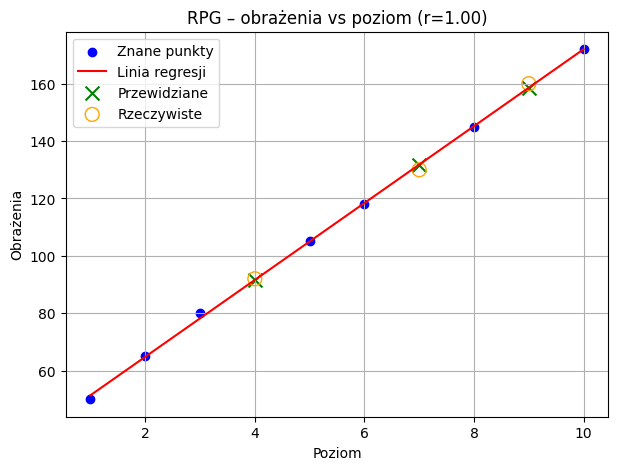

In [20]:
# Zad.1
# Projektujesz moduł AI balansu w grze RPG.
# Chcesz sprawdzić, jak średnie obrażenia rosną wraz z poziomem postaci,
# żeby dobrać skalowanie przeciwników i nagród.


# Dane
# x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] # poziom postaci
# y = [50, 65, 80, 92, 105, 118, 130, 145, 160, 172] # średnie obrażenia

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1,11, dtype=float)

y_true = np.array([50, 65, 80, 92, 105, 118, 130, 145, 160, 172])
missing = np.array([3,6,8])
known = np.setdiff1d(np.arange(len(x)), missing)


# a, b = regression(x[known], y_true[known])
a,b = np.polyfit(x[known], y_true[known], 1) # wbudowana regresja liniowa w numpy
y_pred = a*x + b

r = np.corrcoef(x[known], y_true[known])[0,1]

print(f"Korelacja = {r:.4f}")


for i in missing:
  print(f"Poziom {int(x[i])}: prawdziwe {y_true[i]}, przewidywane {y_pred[i]:.2f}, różnica {y_pred[i]-y_true[i]}")


# Wykres
plt.figure(figsize=(7,5))
plt.scatter(x[known], y_true[known], color="blue", label="Znane punkty")
plt.plot(x, y_pred, color="red", label="Linia regresji")
plt.scatter(x[missing], y_pred[missing], marker="x", color="green", s=100, label="Przewidziane")
plt.scatter(x[missing], y_true[missing], facecolors='none', edgecolors='orange', s=100, label="Rzeczywiste")
plt.title(f"RPG – obrażenia vs poziom (r={r:.2f})")
plt.xlabel("Poziom"); plt.ylabel("Obrażenia")
plt.legend(); plt.grid(True); plt.show()






In [ ]:
# Zadanie 2
# Testujesz działanie gry na różnych komputerach.
# Chcesz sprawdzić, jak liczba włączonych efektów graficznych wpływa na płynność gry (FPS)
# Dane
# x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # liczba efektów
# y = [160, 152, 140, 128, 118, 111, 100, 94, 83, 77] # średni FPS

In [ ]:
# Zadanie 3
# W grze ekonomicznej gracze mogą zarabiać monety w zależności od czasu gry.
# Dane
# x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] # czas gry (h/dzień)
# y = [500 + 100*np.sin(i) for i in x] # średnie zarobki w monetach